# Chapter 10. Quantum Regression

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 2**

## 학습 목표
- 변분 양자 회로로 비선형 함수를 회귀하기
- Data re-uploading의 효과를 회귀 문제로 체감
- 회로 깊이와 함수 표현력의 관계를 정량적으로 확인

In [3]:
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 10.1 목표 함수
주파수가 다른 두 코사인의 합을 학습한다. 
$f(x) = 0.6\cos(x) + 0.3\cos(3x)$

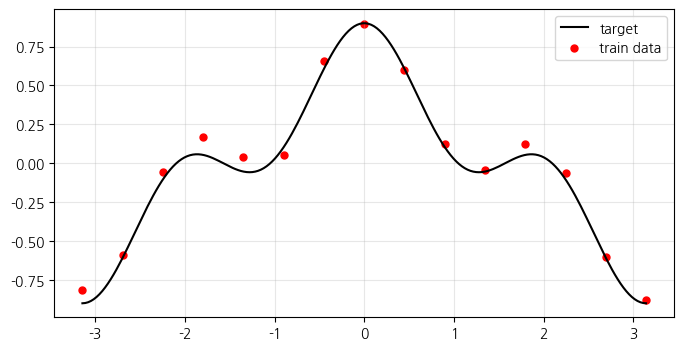

In [4]:
def target(x):
    return 0.6 * np.cos(x) + 0.3 * np.cos(3 * x)

rng = np.random.RandomState(0)
x_train = np.linspace(-np.pi, np.pi, 15)
y_train = target(x_train) + 0.05 * rng.randn(len(x_train))
x_plot = np.linspace(-np.pi, np.pi, 200)
y_plot = target(x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, y_plot, 'k-', label='target')
plt.scatter(x_train, y_train, color='red', s=25, label='train data')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 10.2 단일 큐비트 회귀 회로 (re-uploading)
회로 깊이 L을 늘려가며 표현력을 확장한다.

In [5]:
dev = qml.device('default.qubit', wires=1)

def make_regressor(n_layers):
    @qml.qnode(dev, interface='autograd', diff_method='backprop')
    def circuit(x, params):
        for layer in range(n_layers):
            # 인코딩 (re-uploading)
            qml.RX(x, wires=0)
            # 변분 회전 3개로 임의의 단일 큐비트 unitary
            qml.Rot(params[3 * layer], params[3 * layer + 1], params[3 * layer + 2], wires=0)
        return qml.expval(qml.PauliZ(0))
    return circuit

## 10.3 회로 깊이별 학습

In [6]:
def train_regressor(n_layers, steps=40):
    circuit = make_regressor(n_layers)
    params = pnp.array(
        rng.uniform(0, 2 * np.pi, 3 * n_layers),
        requires_grad=True,
    )
    def cost(p):
        preds = pnp.stack([circuit(x, p) for x in x_train])
        return pnp.mean((preds - y_train) ** 2)
    opt = qml.AdamOptimizer(0.1)
    for _ in range(steps):
        params = opt.step(cost, params)
    return params, cost(params), circuit

results = {}
for L in [2, 4, 6]:
    p, c, circ = train_regressor(L)
    results[L] = (p, c, circ)
    print(f'L={L}: 학습 MSE = {c:.4f}')

L=2: 학습 MSE = 0.0531
L=4: 학습 MSE = 0.0103
L=6: 학습 MSE = 0.0057


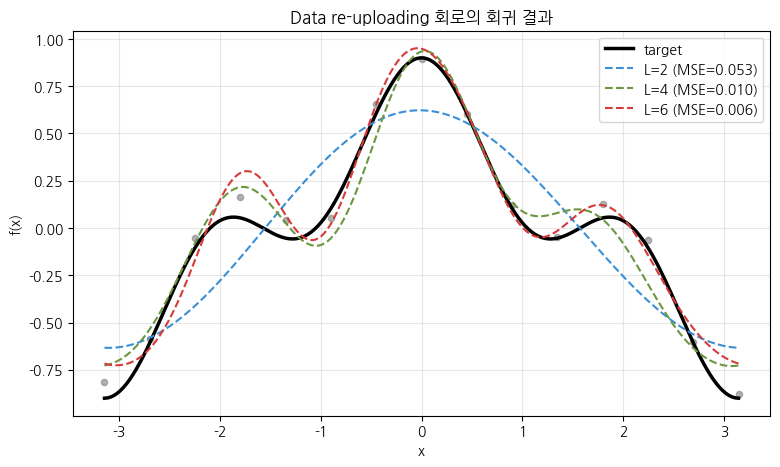

In [7]:
# 학습 결과 시각화
plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_plot, 'k-', lw=2.5, label='target')
plt.scatter(x_train, y_train, color='gray', s=20, alpha=0.6)

colors = ['#3b8fd6', '#6c963f', '#d63b3b']
for (L, (p, c, circ)), col in zip(results.items(), colors):
    y_pred = np.array([circ(x, p) for x in x_plot])
    plt.plot(x_plot, y_pred, '--', color=col, label=f'L={L} (MSE={c:.3f})')

plt.legend(); plt.grid(alpha=0.3)
plt.title('Data re-uploading 회로의 회귀 결과')
plt.xlabel('x'); plt.ylabel('f(x)')
plt.show()

**관찰.** 
- L=2: 주파수 1까지만 표현 → 큰 거시 형태만 잡음
- L=4: 주파수 3까지 표현 가능 → 잘 맞춤
- L=6: 약간의 과적합 가능성, MSE는 더 낮아짐

## 10.4 회로 깊이와 MSE
보다 체계적으로 L에 따른 학습 MSE를 측정한다.

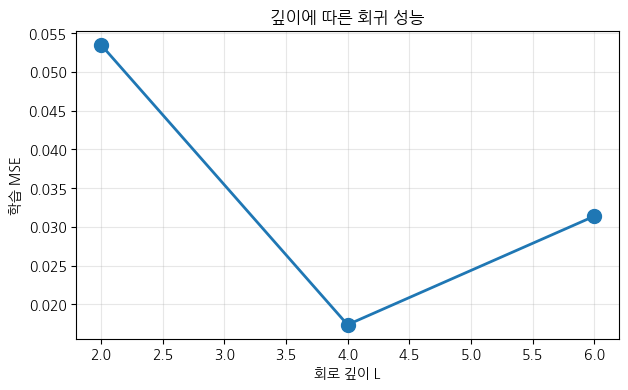

In [8]:
layer_sweep = [2, 4, 6]
mses = []
for L in layer_sweep:
    _, c, _ = train_regressor(L, steps=30)
    mses.append(float(c))

plt.figure(figsize=(7, 4))
plt.plot(layer_sweep, mses, 'o-', lw=2, markersize=10)
plt.xlabel('회로 깊이 L'); plt.ylabel('학습 MSE')
plt.title('깊이에 따른 회귀 성능')
plt.grid(alpha=0.3)
plt.show()

## 10.5 정리
- 양자 회귀는 PQC의 출력값을 그대로 실수로 사용한다.
- Data re-uploading 횟수가 표현 가능한 주파수의 상한을 결정한다.
- 목표 함수의 "필요 주파수"보다 충분한 깊이의 회로가 필요하다.